# RESULTS

In this file 

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, f1_score, roc_auc_score, average_precision_score

In [2]:
import json

# 1. Define the exact path where the file was saved
file_path = "results/experiments_map.json"

# 2. Open the file in read mode ('r') and load it
with open(file_path, "r", encoding="utf-8") as f:
    experiments_map = json.load(f)

experiments_map["Random Benchmark (Stratified)"] = "benchmark_random"

# Perfect! Your dictionary is now fully recovered
print(f"Experiments map loaded successfully. Total experiments: {len(experiments_map)}")

Experiments map loaded successfully. Total experiments: 108


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve, f1_score, roc_auc_score,
    precision_score, recall_score, classification_report
)

def evaluate_experiments(plots_filter, threshold_05=False, results_folder="results", experiments_map=None):
    """
    Evaluates, prints metrics, and plots curves for selected ML experiments.
    Rankings are automatically sorted by F1-Score (descending).
    """

    comparison_results = []
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 7))

    for name, prefix in experiments_map.items():
        if name not in plots_filter:
            continue

        pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
        feat_file = os.path.join(results_folder, f"{prefix}_feature_importance.csv")
        
        if not os.path.exists(pred_file):
            print(f"⚠️ Warning: Missing prediction file for '{name}'. Skipping...")
            continue
            
        print(f"\n" + "="*60)
        print(f"ANALYZING EXPERIMENT: {name}")
        print("="*60)
        
        df_preds = pd.read_csv(pred_file)
        all_y_true = df_preds["y_true"]
        all_y_prob = df_preds["y_prob"]

        # --- THRESHOLD STRATEGY ---
        if threshold_05:
            current_threshold = 0.5
            print("⚙️ Strategy: Using Fixed Standard Threshold (0.5)")
        else:
            # Calculate precision and recall across all possible thresholds
            precisions, recalls, thresholds_pr = precision_recall_curve(all_y_true, all_y_prob)
            
            # Compute F1 scores for each threshold, avoiding division by zero
            f1_scores = np.divide(
                2 * (precisions * recalls),
                (precisions + recalls),
                out=np.zeros_like(precisions),
                where=(precisions + recalls) != 0
            )
            
            # precision_recall_curve returns len(thresholds) = len(precisions) - 1
            # We exclude the last element of f1_scores (where recall is 0) to align the indices
            best_idx = np.argmax(f1_scores[:-1])
            current_threshold = thresholds_pr[best_idx]
            
            print(f"🎯 Strategy: Maximizing F1-Score | Optimal Threshold: {current_threshold:.3f}")

        # Convert probabilities to hard binary predictions using the chosen threshold
        all_y_pred = (all_y_prob >= current_threshold).astype(int)

        # Calculate standard metrics
        f1 = f1_score(all_y_true, all_y_pred)
        prec = precision_score(all_y_true, all_y_pred, zero_division=0)
        rec = recall_score(all_y_true, all_y_pred)
        roc_auc = roc_auc_score(all_y_true, all_y_prob)
        
        num_features = len(pd.read_csv(feat_file)) if os.path.exists(feat_file) else 0
        
        # Collect execution results
        comparison_results.append({
            'Experiment': name,
            'Opt. Threshold': round(current_threshold, 3),
            'F1-Score': round(f1, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'ROC AUC': round(roc_auc, 4),
            'Features': num_features
        })

        if os.path.exists(feat_file):
            print(f"\n--- TOP 10 PREDICTORS ({name}) ---")
            df_feat = pd.read_csv(feat_file)
            print(df_feat.head(10).to_string(index=False))
        
        print(f"\nClassification Report ({name}):")
        print(classification_report(all_y_true, all_y_pred))

        # Plot ROC Curve
        fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
        ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
        # Plot Precision-Recall Curve
        prec_curve, rec_curve, _ = precision_recall_curve(all_y_true, all_y_prob)
        # Using average_precision_score just for the plot legend as it's standard practice
        from sklearn.metrics import average_precision_score
        avg_prec = average_precision_score(all_y_true, all_y_prob)
        ax_pr.plot(rec_curve, prec_curve, lw=2, label=f'{name} (AP = {avg_prec:.3f})')

    # ============================================================
    # FINAL RANKING TABLE (SORTED BY F1-SCORE DESCENDING)
    # ============================================================
    if comparison_results:
        # Higher F1-Score means a better balance between precision and recall
        df_results = pd.DataFrame(comparison_results).sort_values(by='F1-Score', ascending=False)
        print("\n" + "#"*80)
        print("       FINAL RANKING (SORTED BY F1-SCORE - HIGHER IS BETTER)")
        print("#"*80)
        print(df_results.to_string(index=False))
    else:
        print("\n❌ No experiments were successfully loaded. Plots will be empty.")
        return

    # Visualizations formatting
    ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(loc='lower right', fontsize=9)
    ax_roc.grid(alpha=0.3)

    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.legend(loc='upper right', fontsize=9)
    ax_pr.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

All the available models that we have, and that we can check their performance are:

In [4]:
models = list(experiments_map.keys())

In [5]:
print(models)

['Only Signals (CERF)', 'Only Signals (CERF) BEST', 'Only INFORM', 'Only INFORM + Only Signals (CERF)', 'Only INFORM + Only Signals (CERF) BEST', 'Only Risk Alerts', 'Only Risk Alerts + Only Signals (CERF)', 'Only Risk Alerts + Only Signals (CERF) BEST', 'Only Risk Alerts + Only INFORM', 'Only Risk Alerts + Only INFORM + Only Signals (CERF)', 'Only Risk Alerts + Only INFORM + Only Signals (CERF) BEST', 'Only Risk Alerts BEST', 'Only Risk Alerts BEST + Only Signals (CERF)', 'Only Risk Alerts BEST + Only Signals (CERF) BEST', 'Only Risk Alerts BEST + Only INFORM', 'Only Risk Alerts BEST + Only INFORM + Only Signals (CERF)', 'Only Risk Alerts BEST + Only INFORM + Only Signals (CERF) BEST', 'Derived Humanitarian Impact', 'Derived Humanitarian Impact + Only Signals (CERF)', 'Derived Humanitarian Impact + Only Signals (CERF) BEST', 'Derived Humanitarian Impact + Only INFORM', 'Derived Humanitarian Impact + Only INFORM + Only Signals (CERF)', 'Derived Humanitarian Impact + Only INFORM + Only 


ANALYZING EXPERIMENT: Only Signals (CERF)
🎯 Strategy: Maximizing F1-Score | Optimal Threshold: 0.480

--- TOP 10 PREDICTORS (Only Signals (CERF)) ---
          feature  importance
           p_sig2    0.425668
protracted_signal    0.228722
     early_signal    0.206315
           h_sig2    0.047467
hard_onset_signal    0.041411
           p_sig1    0.032718
           p_sig3    0.012066
           h_sig1    0.005633

Classification Report (Only Signals (CERF)):
              precision    recall  f1-score   support

         0.0       1.00      0.83      0.91      3984
         1.0       0.09      0.83      0.16        76

    accuracy                           0.83      4060
   macro avg       0.54      0.83      0.53      4060
weighted avg       0.98      0.83      0.89      4060


ANALYZING EXPERIMENT: Only Signals (CERF) BEST
🎯 Strategy: Maximizing F1-Score | Optimal Threshold: 0.771

--- TOP 10 PREDICTORS (Only Signals (CERF) BEST) ---
          feature  importance
     early_sign

/Users/gal.lagelpibuxade/Desktop/Master_thesis/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gal.lagelpibuxade/Desktop/Master_thesis/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gal.lagelpibuxade/Desktop/Master_thesis/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

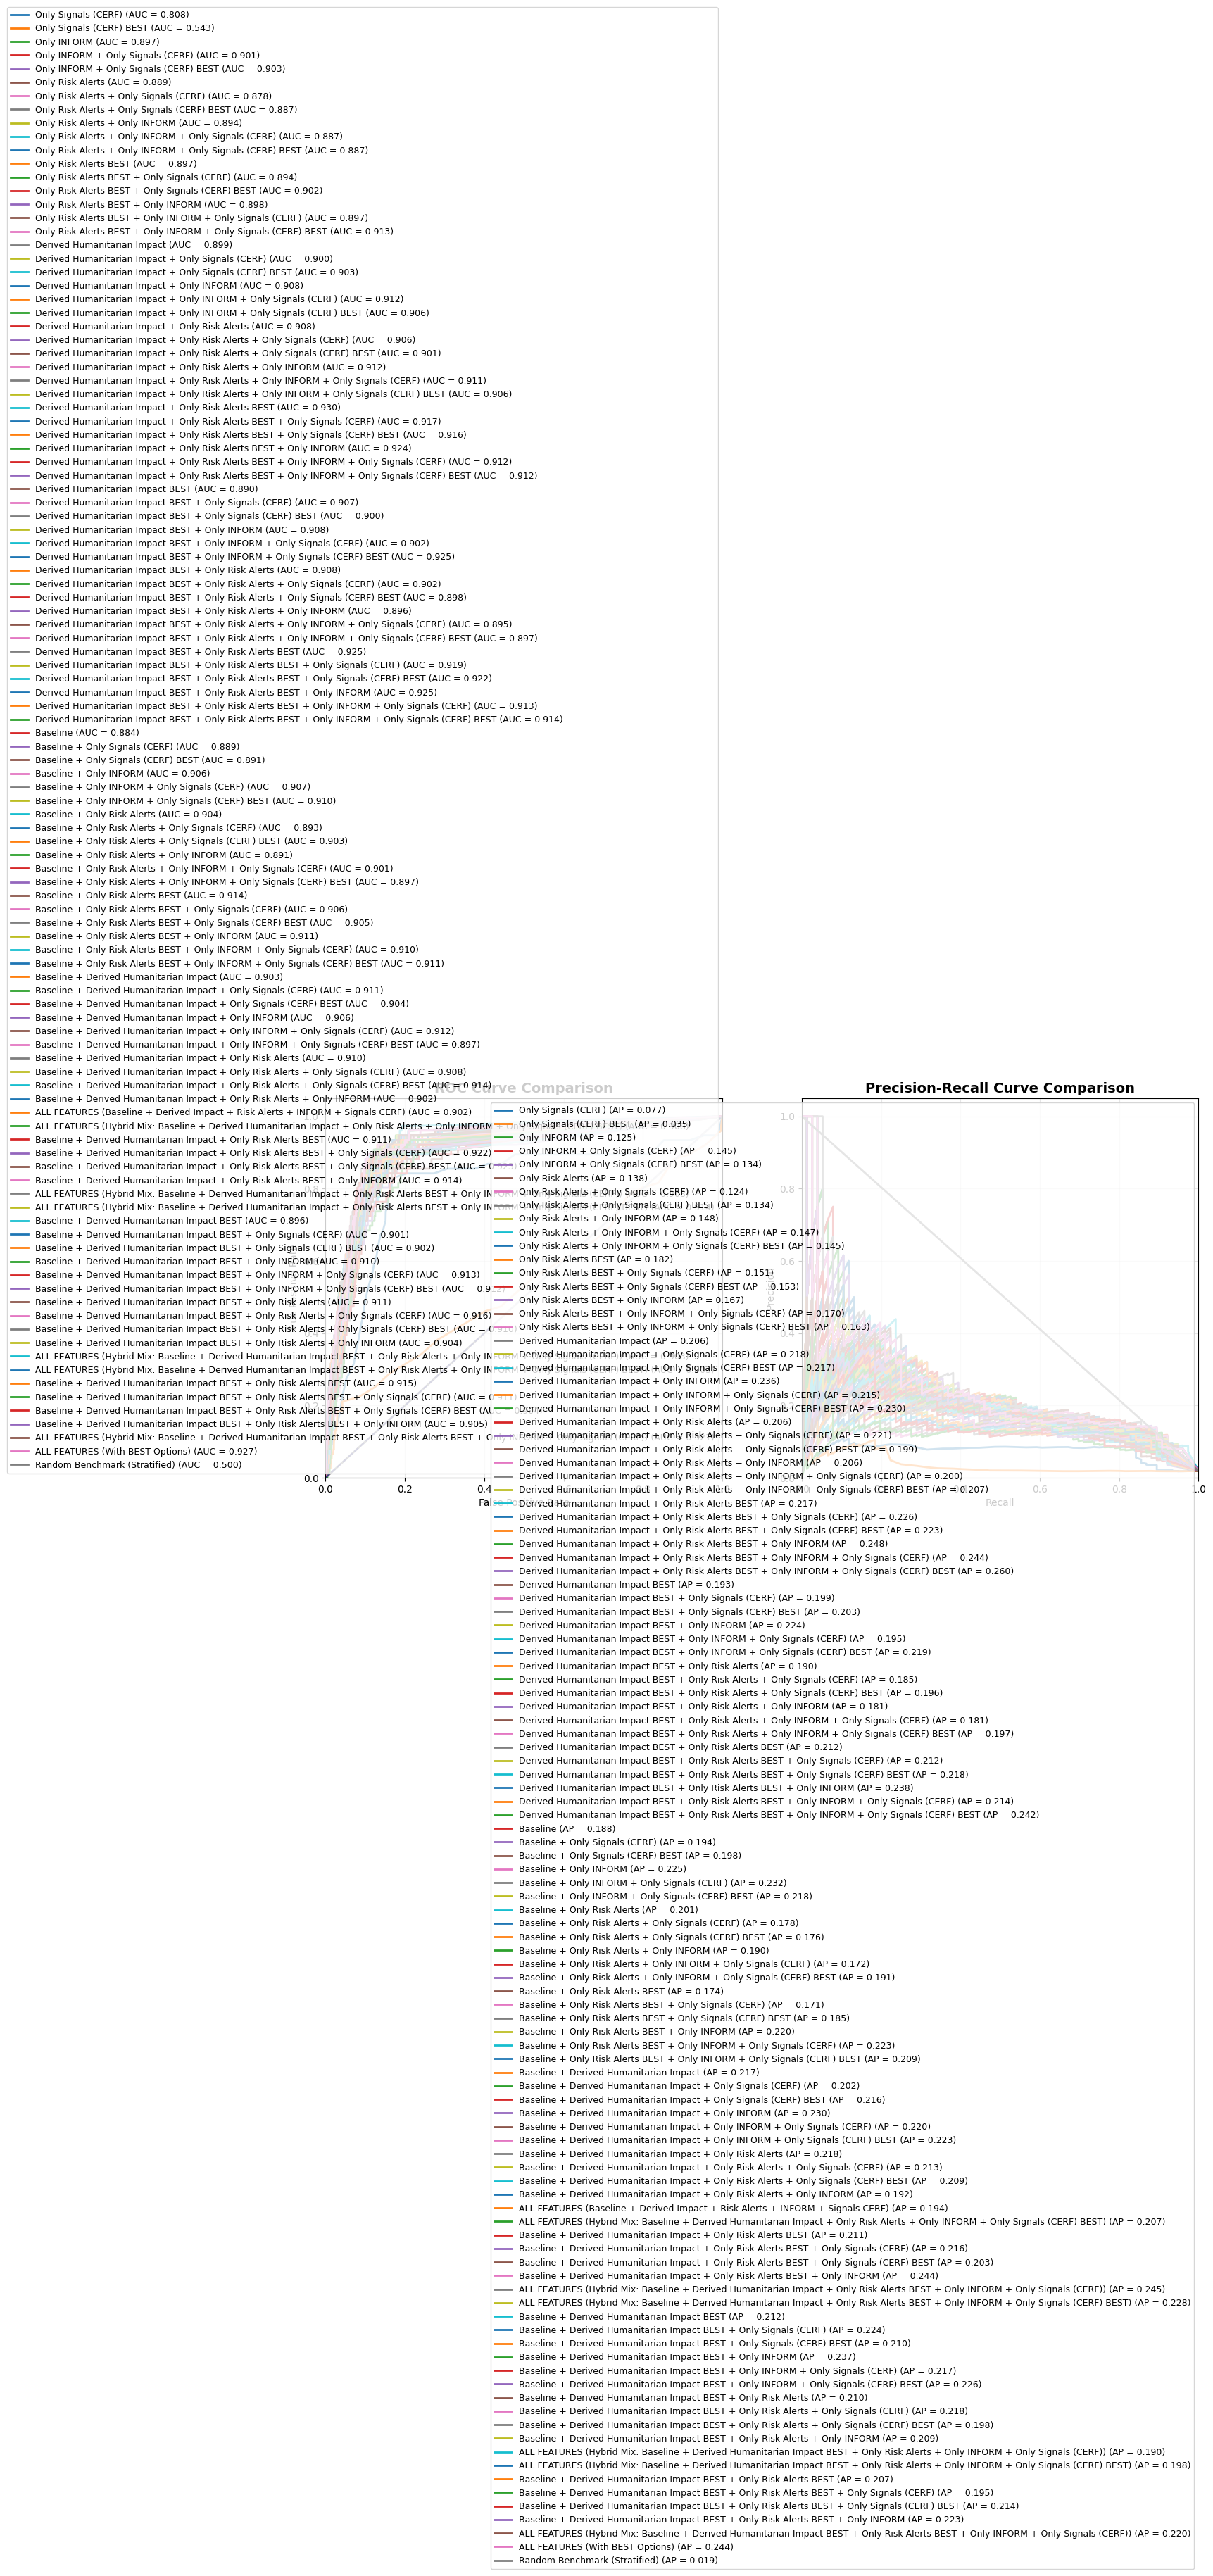

In [6]:
evaluate_experiments(plots_filter=models, threshold_05=False, experiments_map=experiments_map)